# Crop Disease Detection using Vision Transformer (ViT)

This notebook builds, trains and evaluates a Vision Transformer model for crop disease detection using TensorFlow and Keras.

Dataset structure:
- train/
  - potato_early_blight/
  - potato_late_blight/
  - potato_healthy/
- validation/
  - same structure as train
- test/
  - same structure as train

In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

2025-10-10 13:07:43.088700: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760101663.268465      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760101663.332138      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
Keras version: 3.8.0


## 1. Data Loading and Preprocessing

In [2]:
# Define paths to data directories
# Update these paths according to your data location
train_dir = '/kaggle/input/rice-dataset/RICE DATASET (aug)/train'
val_dir = '/kaggle/input/rice-dataset/RICE DATASET (aug)/val'
test_dir = '/kaggle/input/rice-dataset/RICE DATASET (aug)/test'

# Image parameters
IMG_SIZE = 224
BATCH_SIZE = 16

# Check if the directories exist
for directory in [train_dir, val_dir, test_dir]:
    if not os.path.exists(directory):
        raise ValueError(f"Directory not found: {directory}")

In [3]:
from tensorflow.keras.applications.densenet import preprocess_input

# Create data augmentation for training images
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,              # Normalize pixel values
    rotation_range=20,           # Random rotation
    width_shift_range=0.2,       # Random horizontal shift
    height_shift_range=0.2,      # Rrandom vertical shift
    shear_range=0.2,             # Shear transformations
    zoom_range=0.2,              # Random zoom
    horizontal_flip=True,        # Random horizontal flip
    brightness_range=(0.8, 1.2), # Brightness adjustment
    fill_mode='nearest'          # Fill strategy for created pixels
)

# Validation and test data should only be normalized, not augmented
val_datagen = keras.preprocessing.image.ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = keras.preprocessing.image.ImageDataGenerator(preprocessing_function=preprocess_input)

# Create data generators for train, validation, and test sets
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Don't shuffle test data to maintain order for evaluation
)

# Get class names and number of classes
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 3500 images belonging to 5 classes.
Found 750 images belonging to 5 classes.
Found 750 images belonging to 5 classes.
Classes: ['Rice___Bacterial_Leaf_Blight', 'Rice___Brown_Spot', 'Rice___Healthy_Rice_Leaf', 'Rice___Leaf_Blast', 'Rice___Leaf_Scald']
Number of classes: 5
Training samples: 3500
Validation samples: 750
Test samples: 750


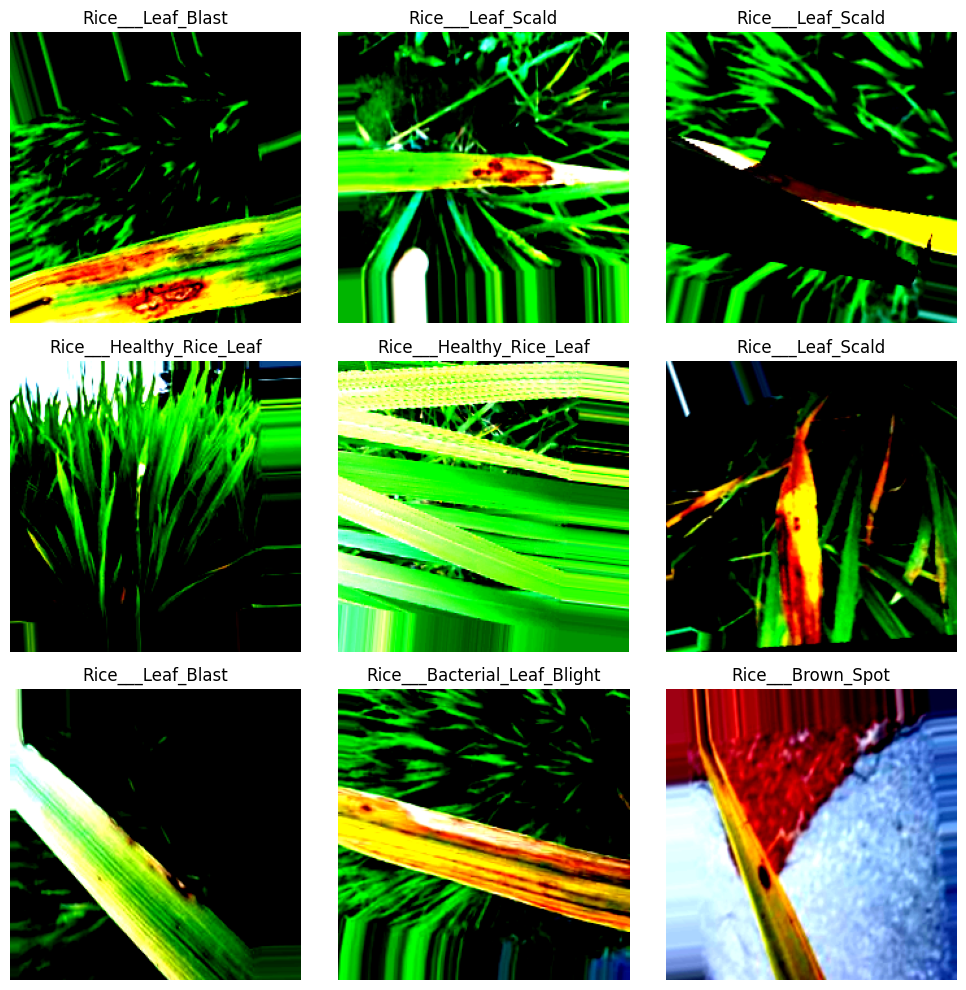

In [4]:
# Visualize some training samples with augmentation
def show_batch(image_batch, label_batch):
    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(image_batch))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i])
        plt.title(class_names[np.argmax(label_batch[i])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Get a batch of training images and labels
image_batch, label_batch = next(train_generator)
show_batch(image_batch, label_batch)

## 2. Model Creation

In [ ]:
from keras.applications import DenseNet121
from tensorflow.keras import regularizers

def create_model():

    # Load the EfficientNetB0 model with pre-trained weights
    base_model = DenseNet121(
        include_top=False,           # Exclude the classification head
        weights='imagenet',          # Pre-trained on ImageNet
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )


    # Freeze the base model layers initially
    base_model.trainable = False
    # Add custom classification head
    inputs = keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)

    # Global average pooling to reduce dimensions
    x = keras.layers.GlobalAveragePooling2D()(x)

    # Add dropout and dense layers for classification
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.4)(x)  # Dropout to prevent overfitting
    x = keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(2e-4))(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

    # Create the model
    model = keras.Model(inputs, outputs)

    return model

# Create the model
model = create_model()
model.summary()

I0000 00:00:1760101694.747152      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,568,965 (28.87 MB)

 Trainable params: 529,413 (2.02 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

## 3. Training

In [6]:

# Set up simplified training parameters
EPOCHS_PHASE1 = 10   # Reduced from 10 for quicker iterations
EPOCHS_PHASE2 = 25  # Reduced from 20 for quicker iterations

# Simplify the optimizer - use standard Adam with fixed learning rate
optimizer = keras.optimizers.Adam(learning_rate=8e-4)  # Fixed learning rate

# Compile the model with simplified settings
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Simplified callbacks - just keep the essential ones
checkpoint_path = "rice_DenseNet121_bestmodel_.h5"
callbacks = [
    # Save the best model based on validation accuracy
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Early stopping to prevent overfitting
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,                # Reduced from 10
        restore_best_weights=True
    )
]


In [7]:
# Phase 1: Train only the top layers (feature extraction)
print("Phase 1: Training only the top layers")
# Ensure base model layers are frozen (not trainable)
base_model = model.layers[1]
base_model.trainable = False

history_phase1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks
)


Phase 1: Training only the top layers


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1760101755.892158     124 service.cc:148] XLA service 0x7d06fc002e50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760101755.893107     124 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1760101758.654122     124 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/219 ━━━━━━━━━━━━━━━━━━━━ 1:55:44 32s/step - accuracy: 0.3750 - loss: 2.1688

I0000 00:00:1760101769.045471     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.5412 - loss: 1.4067
Epoch 1: val_accuracy improved from -inf to 0.74267, saving model to rice_DenseNet121_bestmodel_.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 164s 608ms/step - accuracy: 0.5416 - loss: 1.4058 - val_accuracy: 0.7427 - val_loss: 0.7640
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.6943 - loss: 0.9451
Epoch 2: val_accuracy improved from 0.74267 to 0.80933, saving model to rice_DenseNet121_bestmodel_.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 67s 306ms/step - accuracy: 0.6943 - loss: 0.9450 - val_accuracy: 0.8093 - val_loss: 0.6189
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.7268 - loss: 0.8466
Epoch 3: val_accuracy improved from 0.80933 to 0.82400, saving model to rice_DenseNet121_bestmodel_.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 67s 304ms/step - accuracy: 0.7268 - loss: 0.8465 - val_accuracy: 0.8240 - val_loss: 0.5286
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.7628 - loss:

In [8]:

base_model = model.layers[1]

len(base_model.layers)

427

In [8]:
print("Phase 2: Fine-tuning the model")

# Access the base model and make some layers trainable
base_model = model.layers[1]
base_model.trainable = True

# Freeze earlier layers, unfreeze later layers
# For VGG16, there are 19 layers - freeze first 14, train last 5
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= 298)  # Only train the last 5 layers

# Use a lower learning rate for fine-tuning
optimizer_finetune = keras.optimizers.Adam(learning_rate=1e-5)  # 10x smaller

# Recompile the model with the new learning rate
model.compile(
    optimizer=optimizer_finetune,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print summary of trainable vs non-trainable layers
print(f"Total layers in the model: {len(model.layers)}")
print(f"Trainable weights: {len(model.trainable_weights)}")
print(f"Non-trainable weights: {len(model.non_trainable_weights)}")

# Continue training
history_phase2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE2,
    initial_epoch=EPOCHS_PHASE1,  # Continue from where we left off
    callbacks=callbacks
)


Phase 2: Fine-tuning the model
Total layers in the model: 8
Trainable weights: 116
Non-trainable weights: 496
Epoch 11/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.7780 - loss: 0.7321
Epoch 11: val_accuracy did not improve from 0.90267
219/219 ━━━━━━━━━━━━━━━━━━━━ 170s 483ms/step - accuracy: 0.7781 - loss: 0.7321 - val_accuracy: 0.8787 - val_loss: 0.4286
Epoch 12/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.7985 - loss: 0.6498
Epoch 12: val_accuracy did not improve from 0.90267
219/219 ━━━━━━━━━━━━━━━━━━━━ 78s 355ms/step - accuracy: 0.7985 - loss: 0.6499 - val_accuracy: 0.8973 - val_loss: 0.4052
Epoch 13/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.8286 - loss: 0.5960
Epoch 13: val_accuracy improved from 0.90267 to 0.90667, saving model to rice_DenseNet121_bestmodel_.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 77s 351ms/step - accuracy: 0.8286 - loss: 0.5960 - val_accuracy: 0.9067 - val_loss: 0.3748
Epoch 14/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step

In [9]:
# Combine the histories from both training phases
history = {}
for key in history_phase1.history.keys():
    history[key] = history_phase1.history[key] + history_phase2.history[key]

# Load the best model weights from checkpoint
model.load_weights(checkpoint_path)
eval_result = model.evaluate(validation_generator)
print(f"Final validation accuracy: {eval_result[1]:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.9602 - loss: 0.2654
Final validation accuracy: 0.9600


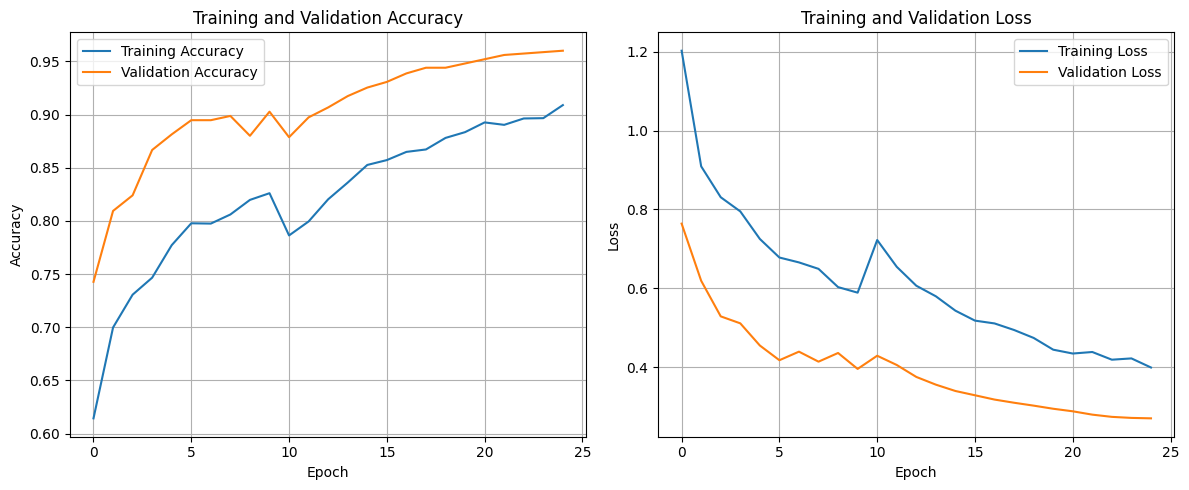

In [10]:
# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 4. Model Evaluation

In [11]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 182ms/step - accuracy: 0.9370 - loss: 0.3093
Test Loss: 0.2873
Test Accuracy: 0.9520


In [12]:
# Get predictions for the test set
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

# Make sure predictions and true labels have the same length
print(f"Number of test samples: {len(y_true)}")
print(f"Number of predictions: {len(y_pred)}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 353ms/step
Number of test samples: 750
Number of predictions: 750


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report

# Calculate additional metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Generate detailed classification report
print("\nClassification Report:")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Create a DataFrame for better visualization
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

Precision: 0.9521
Recall: 0.9520
F1 Score: 0.9519

Classification Report:
                              precision    recall  f1-score   support

Rice___Bacterial_Leaf_Blight       0.94      0.91      0.92       150
           Rice___Brown_Spot       0.94      0.99      0.97       150
    Rice___Healthy_Rice_Leaf       1.00      0.99      0.99       150
           Rice___Leaf_Blast       0.93      0.93      0.93       150
           Rice___Leaf_Scald       0.95      0.95      0.95       150

                    accuracy                           0.95       750
                   macro avg       0.95      0.95      0.95       750
                weighted avg       0.95      0.95      0.95       750



,precision,recall,f1-score,support
Rice___Bacterial_Leaf_Blight,0.937931,0.906667,0.922034,150.000
Rice___Brown_Spot,0.943038,0.993333,0.967532,150.000
Rice___Healthy_Rice_Leaf,1.000000,0.986667,0.993289,150.000
Rice___Leaf_Blast,0.926667,0.926667,0.926667,150.000
Rice___Leaf_Scald,0.953020,0.946667,0.949833,150.000
accuracy,0.952000,0.952000,0.952000,0.952
macro avg,0.952131,0.952000,0.951871,750.000
weighted avg,0.952131,0.952000,0.951871,750.000


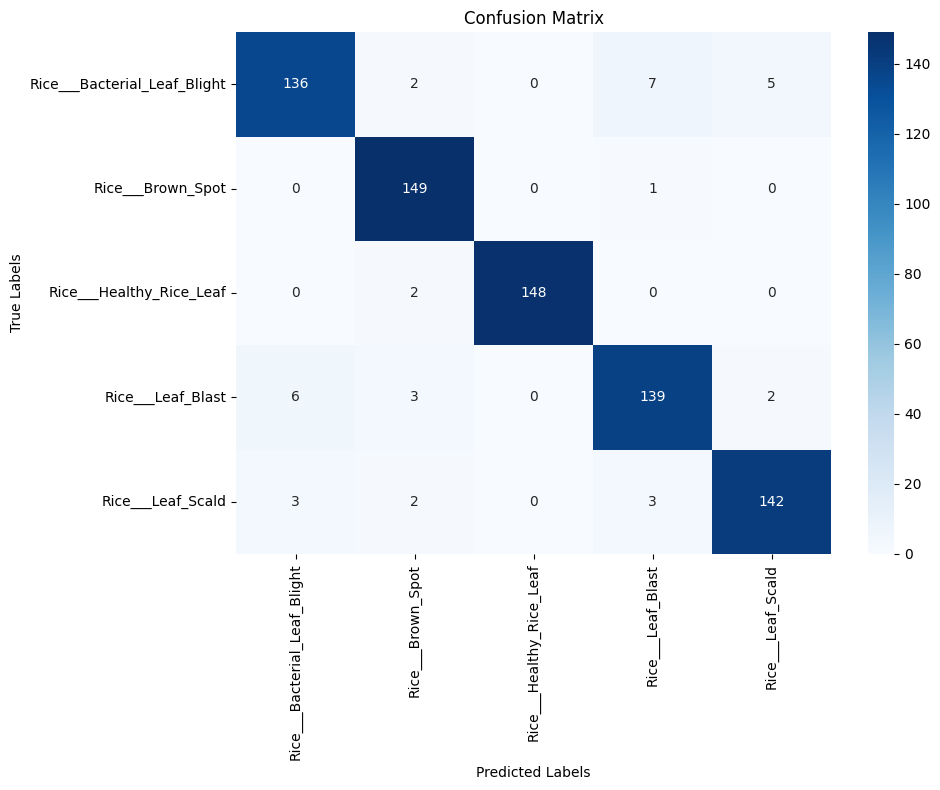

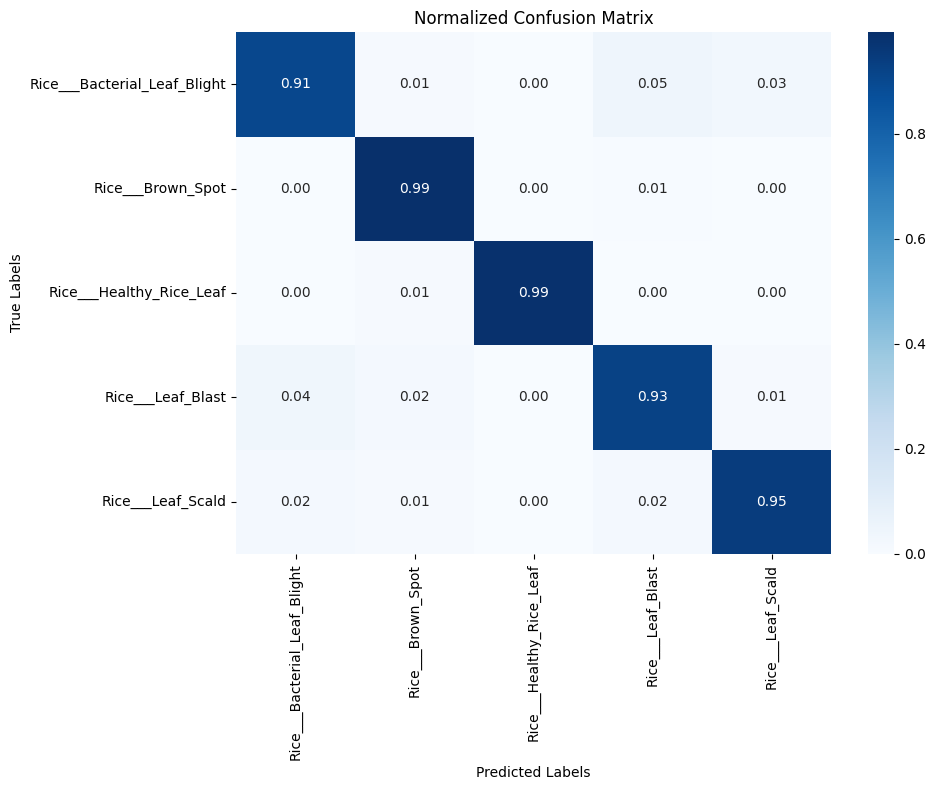

In [14]:
# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Plot normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

## 5. Prediction on New Images

In [ ]:
def predict_disease(image_path_or_url, is_url=False):
    """
    Predict crop disease from an image file or URL

    Args:
        image_path_or_url (str): Path to local image or URL
        is_url (bool): Flag to indicate if input is a URL

    Returns:
        tuple: (predicted_class_name, confidence)
    """
    try:
        # Load the image
        if is_url:
            response = requests.get(image_path_or_url)
            img = Image.open(BytesIO(response.content))
        else:
            img = Image.open(image_path_or_url)

        # Convert to RGB if needed (handle PNG transparency)
        if img.mode != 'RGB':
            img = img.convert('RGB')

        # Preprocess the image
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))
        img_array = keras.preprocessing.image.img_to_array(img_resized)
        img_array = img_array / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make prediction
        predictions = model.predict(img_array, verbose=0)

        # Get the predicted class and confidence
        predicted_class_idx = np.argmax(predictions[0])
        confidence = float(predictions[0][predicted_class_idx])
        predicted_class_name = class_names[predicted_class_idx]

        # Display the image with prediction
        plt.figure(figsize=(8, 6))
        plt.imshow(img_resized)
        plt.title(f"Prediction: {predicted_class_name}\nConfidence: {confidence:.2f}", fontsize=14)
        plt.axis('off')
        plt.show()

        # Print all class probabilities
        print("Class probabilities:")
        for i, (cls, prob) in enumerate(zip(class_names, predictions[0])):
            print(f"{cls}: {prob:.4f}")

        return predicted_class_name, confidence

    except Exception as e:
        print(f"Error occurred: {str(e)}")
        return None, None

In [ ]:
# Example 1: Predict from a local file
# Update with path to your test image
# predict_disease("path/to/test_image.jpg")

# Example 2: Predict from a URL
# predict_disease("https://example.com/crop_image.jpg", is_url=True)

In [15]:
# Save the trained model for future use
model.save('ricee_DenseNet121_save.h5')
print("Model saved successfully!")

Model saved successfully!


## Conclusion

In this notebook, we built a Vision Transformer (ViT) model using EfficientNetB0 as the base architecture for crop disease detection. We:

1. Loaded and preprocessed the dataset with data augmentation
2. Created the model architecture
3. Trained the model using a two-phase approach (feature extraction and fine-tuning)
4. Evaluated the model performance using various metrics
5. Created a function to make predictions on new images

The model can be further improved by:
- Trying different architectures
- Implementing more advanced augmentation techniques
- Experimenting with different learning rates and optimizers
- Using techniques like gradient accumulation for larger batch sizes
- Applying more advanced regularization techniques